#  Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Excel/CSV File

In [2]:
df = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\Loan Analysis Project\Excel\Finacal Loan .csv", encoding='latin1')

#  Basic Info

In [3]:
 print("\n--- Dataset Shape ---")
print(df.shape)


--- Dataset Shape ---
(38576, 25)


In [4]:
print("\n--- First 5 Rows ---")
print(df.head())


--- First 5 Rows ---
        id address_state application_type emp_length              emp_title  \
0  1077430            GA       INDIVIDUAL   < 1 year                  Ryder   
1  1072053            CA       INDIVIDUAL    9 years         MKC Accounting   
2  1069243            CA       INDIVIDUAL    4 years  Chemat Technology Inc   
3  1041756            TX       INDIVIDUAL   < 1 year    barnes distribution   
4  1068350            IL       INDIVIDUAL  10+ years          J&J Steel Inc   

  grade home_ownership  issue_date last_credit_pull_date last_payment_date  \
0     C           RENT  11-02-2021            13-09-2021        13-04-2021   
1     E           RENT  01-01-2021            14-12-2021        15-01-2021   
2     C           RENT  05-01-2021            12-12-2021        09-01-2021   
3     B       MORTGAGE  25-02-2021            12-12-2021        12-03-2021   
4     A       MORTGAGE  01-01-2021            14-12-2021        15-01-2021   

   ... sub_grade        term verif

In [5]:
print("\n--- Column Info ---")
print(df.info())


--- Column Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   address_state          38576 non-null  object 
 2   application_type       38576 non-null  object 
 3   emp_length             38576 non-null  object 
 4   emp_title              37138 non-null  object 
 5   grade                  38576 non-null  object 
 6   home_ownership         38576 non-null  object 
 7   issue_date             38576 non-null  object 
 8   last_credit_pull_date  38576 non-null  object 
 9   last_payment_date      38576 non-null  object 
 10  loan_status            38576 non-null  object 
 11  Good v Bad Loan        38576 non-null  object 
 12  next_payment_date      38576 non-null  object 
 13  member_id              38576 non-null  int64  
 14  purpose                38576 non-

#  Data Cleaning

In [8]:
# Standardize column names
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [9]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [10]:
# Missing values summary
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
id                          0
address_state               0
application_type            0
emp_length                  0
emp_title                1438
grade                       0
home_ownership              0
issue_date                  0
last_credit_pull_date       0
last_payment_date           0
loan_status                 0
good_v_bad_loan             0
next_payment_date           0
member_id                   0
purpose                     0
sub_grade                   0
term                        0
verification_status         0
annual_income               0
dti                         0
installment                 0
int_rate                    0
loan_amount                 0
total_acc                   0
total_payment               0
dtype: int64


In [17]:
# Numeric → fill with median
num_cols = df.select_dtypes(include=["number"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [19]:
# Categorical → fill with mode
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Basic EDA

In [22]:
print("\n--- Summary Statistics (Numeric) ---")
print(df.describe().T)


--- Summary Statistics (Numeric) ---
                 count           mean            std         min          25%  \
id             38576.0  681037.061385  211324.578218  54734.0000  513517.0000   
member_id      38576.0  847651.506299  266810.456860  70699.0000  662978.7500   
annual_income  38576.0   69644.540310   64293.681045   4000.0000   41500.0000   
dti            38576.0       0.133274       0.066662      0.0000       0.0821   
installment    38576.0     326.862965     209.092000     15.6900     168.4500   
int_rate       38576.0       0.120488       0.037164      0.0542       0.0932   
loan_amount    38576.0   11296.066855    7460.746022    500.0000    5500.0000   
total_acc      38576.0      22.132544      11.392282      2.0000      14.0000   
total_payment  38576.0   12263.348533    9051.104777     34.0000    5633.0000   

                       50%           75%           max  
id             662728.0000  8.365060e+05  1.077501e+06  
member_id      847356.5000  1.045652e

In [23]:
print("\n--- Category Distribution ---")
for col in cat_cols:
    print(f"\n{col}:\n", df[col].value_counts().head())


--- Category Distribution ---

address_state:
 address_state
CA    6894
NY    3701
FL    2773
TX    2664
NJ    1822
Name: count, dtype: int64

application_type:
 application_type
INDIVIDUAL    38576
Name: count, dtype: int64

emp_length:
 emp_length
10+ years    8870
< 1 year     4575
2 years      4382
3 years      4088
4 years      3428
Name: count, dtype: int64

emp_title:
 emp_title
US Army            1573
Bank of America     109
IBM                  67
AT&T                 63
Wells Fargo          57
Name: count, dtype: int64

grade:
 grade
B    11674
A     9689
C     7904
D     5182
E     2786
Name: count, dtype: int64

home_ownership:
 home_ownership
RENT        18439
MORTGAGE    17198
OWN          2838
OTHER          98
NONE            3
Name: count, dtype: int64

issue_date:
 issue_date
11-12-2021    2188
11-11-2021    2120
11-10-2021    2025
11-09-2021    1980
11-08-2021    1873
Name: count, dtype: int64

last_credit_pull_date:
 last_credit_pull_date
16-05-2021    10041
16-04-

# Visualizations

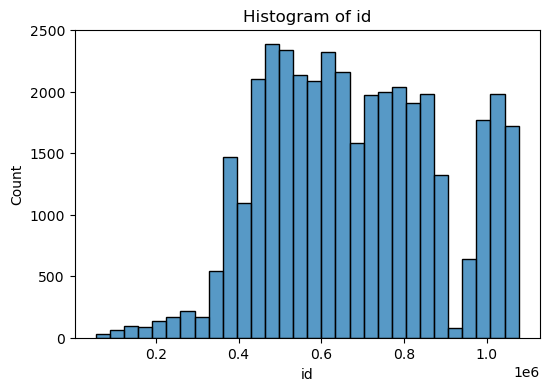

In [24]:
# Histogram of first numeric column
plt.figure(figsize=(6,4))
sns.histplot(df[num_cols[0]], bins=30)
plt.title(f"Histogram of {num_cols[0]}")
plt.show()

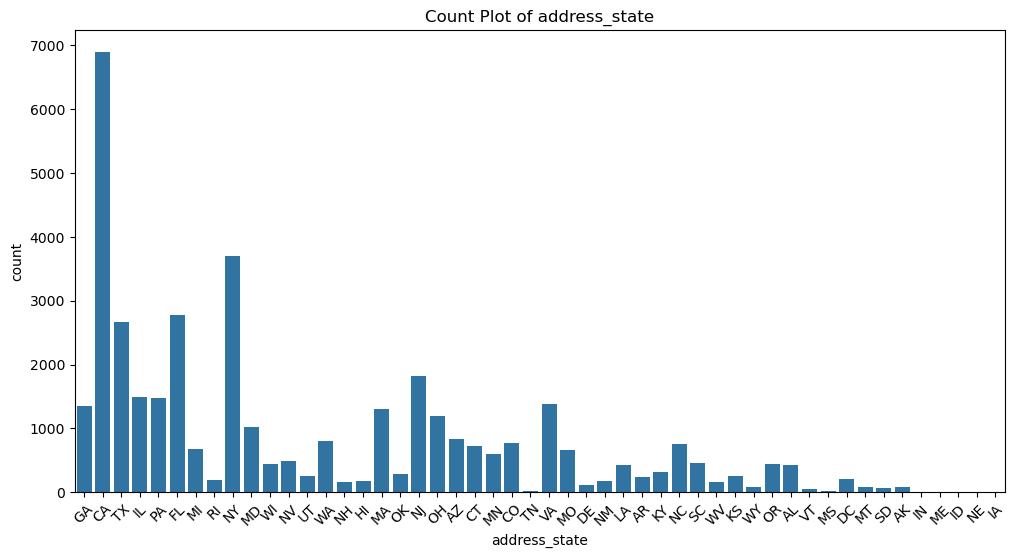

In [26]:
# Count plot of first categorical column
plt.figure(figsize=(12,6))
sns.countplot(x=df[cat_cols[0]])
plt.xticks(rotation=45)
plt.title(f"Count Plot of {cat_cols[0]}")
plt.show()

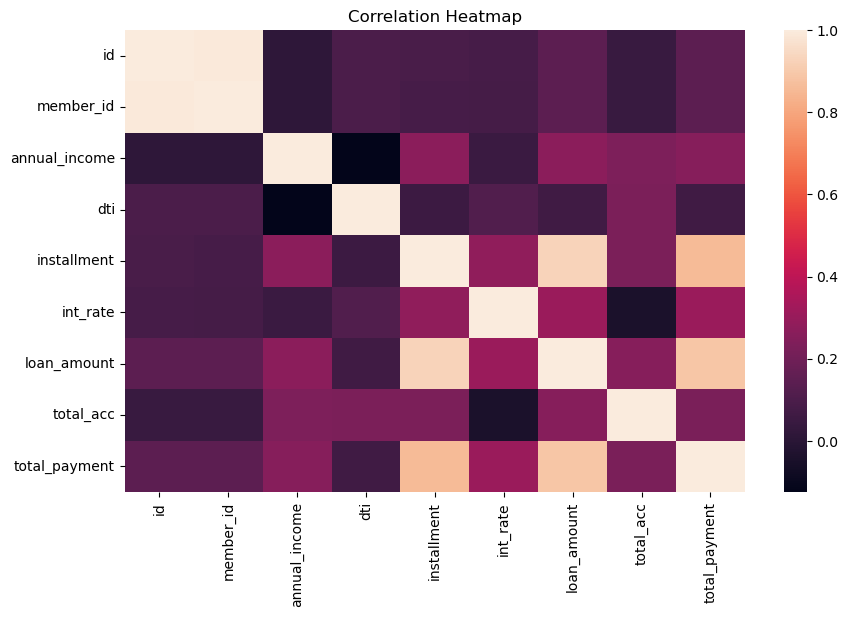

In [27]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=False)
plt.title("Correlation Heatmap")
plt.show()